## Setup: Import Libraries and Load Data

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# Load the dataset (must be in the same folder as this notebook)
df = pd.read_csv("agriculture_yield_dataset.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


## Q1. Dataset Overview
Load the dataset and answer:
- How many rows and columns are present?
- What are the names of all columns?
- Display the first 10 records.

In [ ]:
# Shape of the dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Column names
print("\nColumn names:")
print(list(df.columns))

Number of rows: 1500
Number of columns: 8

Column names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']


In [ ]:
# First 10 records
df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


**Answer:** The dataset has **1500 rows and 8 columns**. The columns are: `rainfall_mm`, `temperature_c`, `fertilizer_kg`, `irrigation_hours`, `soil_ph`, `crop_type`, `soil_type`, and `yield_ton_per_hectare`.

## Q2. Data Types and Missing Values
- Check the data type of each column.
- Identify whether any missing values are present.
- If missing values exist, mention the affected columns.

In [4]:
# Data type of each column
print(df.dtypes)

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                    str
soil_type                    str
yield_ton_per_hectare    float64
dtype: object


In [5]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing values per column:\n")
print(missing_values)

print("\nTotal missing values in the dataset:", missing_values.sum())

Missing values per column:

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Total missing values in the dataset: 0


**Answer:** Five columns (`rainfall_mm`, `temperature_c`, `fertilizer_kg`, `irrigation_hours`, `soil_ph`, `yield_ton_per_hectare`) are numeric (`float64`), and two columns (`crop_type`, `soil_type`) are categorical (object/string). There are **no missing values** in any column of this dataset.

## Q3. Descriptive Statistics
Generate summary statistics for all numerical features and answer:
- Which feature has the highest mean value?
- Which feature has the highest standard deviation?

In [6]:
# Summary statistics for numerical columns
df.describe()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


In [7]:
numeric_df = df.select_dtypes(include=[np.number])

means = numeric_df.mean().sort_values(ascending=False)
stds = numeric_df.std().sort_values(ascending=False)

print("Mean of each numeric feature (highest to lowest):")
print(means)
print(f"\n>> Feature with the HIGHEST MEAN: '{means.idxmax()}' ({means.max():.2f})")

print("\nStandard deviation of each numeric feature (highest to lowest):")
print(stds)
print(f"\n>> Feature with the HIGHEST STANDARD DEVIATION: '{stds.idxmax()}' ({stds.max():.2f})")

Mean of each numeric feature (highest to lowest):
rainfall_mm              754.054667
fertilizer_kg            148.744067
temperature_c             27.749467
soil_ph                    6.759133
irrigation_hours           5.403267
yield_ton_per_hectare      5.028793
dtype: float64

>> Feature with the HIGHEST MEAN: 'rainfall_mm' (754.05)

Standard deviation of each numeric feature (highest to lowest):
rainfall_mm              255.097216
fertilizer_kg             56.990279
temperature_c              5.758101
irrigation_hours           2.584329
yield_ton_per_hectare      0.968282
soil_ph                    0.719742
dtype: float64

>> Feature with the HIGHEST STANDARD DEVIATION: 'rainfall_mm' (255.10)


**Answer:** `rainfall_mm` has both the highest mean (~754 mm) and the highest standard deviation (~255 mm) among the numerical features. This makes sense since rainfall is measured in much larger units (mm) compared to the other features.

## Q4. Distribution Analysis
Create histograms for:
- `rainfall_mm`
- `temperature_c`
- `fertilizer_kg`
- `yield_ton_per_hectare`

Write 2–3 observations from each histogram.

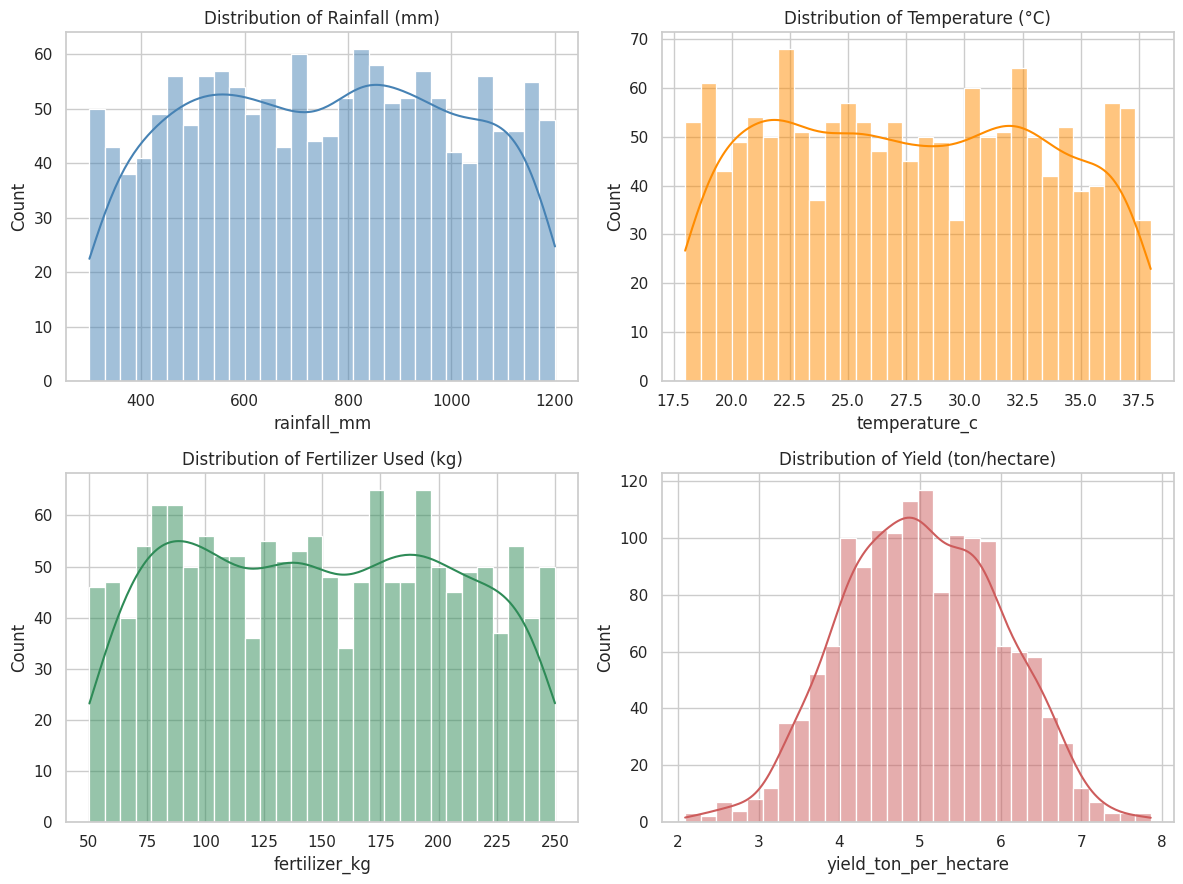

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.histplot(df['rainfall_mm'], bins=30, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribution of Rainfall (mm)')

sns.histplot(df['temperature_c'], bins=30, kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Distribution of Temperature (°C)')

sns.histplot(df['fertilizer_kg'], bins=30, kde=True, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Distribution of Fertilizer Used (kg)')

sns.histplot(df['yield_ton_per_hectare'], bins=30, kde=True, ax=axes[1, 1], color='indianred')
axes[1, 1].set_title('Distribution of Yield (ton/hectare)')

plt.tight_layout()
plt.show()

**Observations:**

**`rainfall_mm`**
1. The values are spread fairly evenly between roughly 300 mm and 1200 mm — the histogram is close to a **uniform distribution** rather than a bell curve.
2. There is no strong peak; bar heights across bins are roughly similar, with mean (~754) and median (~761) very close together.
3. No obvious outliers — the range looks like a designed/simulated spread rather than naturally skewed real-world rainfall data.

**`temperature_c`**
1. Like rainfall, temperature is also roughly **uniformly distributed** between 18°C and 38°C, with no single dominant range.
2. Mean (~27.7°C) and median (~27.7°C) are almost identical, confirming a flat, symmetric spread.
3. No long tail or outliers are visible on either side.

**`fertilizer_kg`**
1. Fertilizer usage is spread fairly evenly from about 50 kg to 250 kg, again showing a **near-uniform shape** rather than a sharp peak.
2. Mean (~148.7) and median (~146.9) are close, indicating symmetry.
3. No visible outliers or gaps in the distribution.

**`yield_ton_per_hectare`**
1. Unlike the input features, the yield histogram shows a clear **bell-shaped, roughly symmetric (approximately normal) distribution** centered around 5 tons/hectare.
2. Most values are concentrated between ~4 and ~6 tons/hectare, with very few records below 3 or above 7.
3. This makes intuitive sense: yield is likely generated as a *combination* of several roughly-uniform input features plus noise, and combining several independent factors tends to produce a more normal/bell-shaped outcome (Central Limit Theorem effect).

## Q5. Crop Type Analysis
- Find the number of records for each crop type.
- Create a count plot (bar chart) for `crop_type`.
- Which crop appears most frequently?

In [9]:
crop_counts = df['crop_type'].value_counts()
print("Number of records per crop type:")
print(crop_counts)

Number of records per crop type:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


/tmp/ipykernel_633/3511630442.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='crop_type', order=crop_counts.index, palette='viridis')


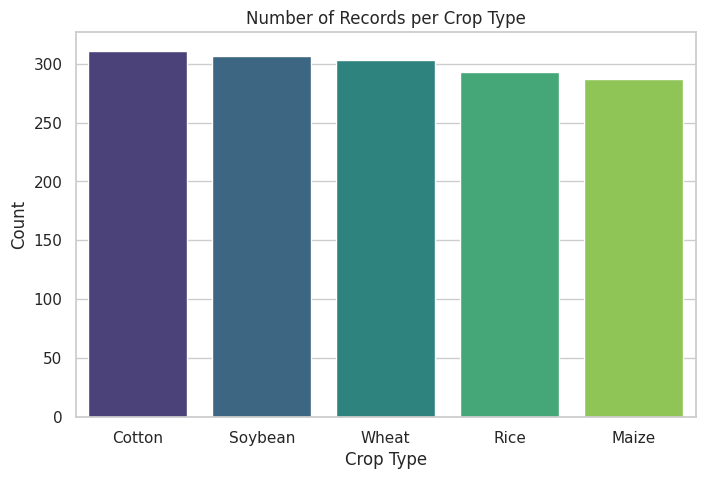


>> Most frequent crop: 'Cotton' with 311 records


In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='crop_type', order=crop_counts.index, palette='viridis')
plt.title('Number of Records per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.show()

print(f"\n>> Most frequent crop: '{crop_counts.idxmax()}' with {crop_counts.max()} records")

**Answer:** `Cotton` appears most frequently (311 records), closely followed by Soybean, Wheat, Rice, and Maize. The five crop types are fairly evenly represented overall (each between ~287 and ~311 records), so the dataset is well balanced across crop types.

## Q6. Soil Type Analysis
- Find the frequency of each soil type.
- Create a count plot for `soil_type`.
- Which soil type is most common?

In [11]:
soil_counts = df['soil_type'].value_counts()
print("Frequency of each soil type:")
print(soil_counts)

Frequency of each soil type:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


/tmp/ipykernel_633/3388131136.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='soil_type', order=soil_counts.index, palette='magma')


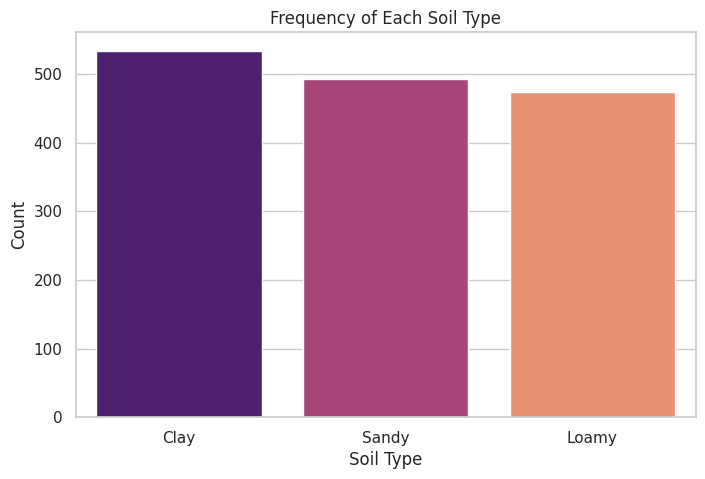


>> Most common soil type: 'Clay' with 534 records


In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='soil_type', order=soil_counts.index, palette='magma')
plt.title('Frequency of Each Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.show()

print(f"\n>> Most common soil type: '{soil_counts.idxmax()}' with {soil_counts.max()} records")

**Answer:** `Clay` is the most common soil type (534 records), followed by Sandy (492) and Loamy (474). The distribution is fairly balanced, with no single soil type dominating overwhelmingly.

## Q7. Yield Distribution
Create a histogram of `yield_ton_per_hectare`.

Answer:
- Is the distribution approximately normal?
- Are there any noticeable outliers?

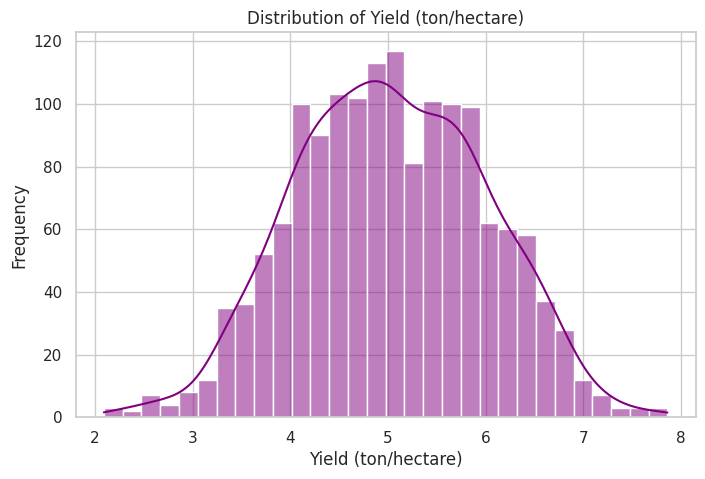

Skewness: -0.001
Kurtosis: -0.36


In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df['yield_ton_per_hectare'], bins=30, kde=True, color='purple')
plt.title('Distribution of Yield (ton/hectare)')
plt.xlabel('Yield (ton/hectare)')
plt.ylabel('Frequency')
plt.show()

print("Skewness:", round(df['yield_ton_per_hectare'].skew(), 3))
print("Kurtosis:", round(df['yield_ton_per_hectare'].kurtosis(), 3))

In [14]:
# Outlier check using the IQR method
Q1 = df['yield_ton_per_hectare'].quantile(0.25)
Q3 = df['yield_ton_per_hectare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['yield_ton_per_hectare'] < lower_bound) | (df['yield_ton_per_hectare'] > upper_bound)]
print(f"IQR bounds: lower = {lower_bound:.2f}, upper = {upper_bound:.2f}")
print(f"Number of outlier records: {len(outliers)}")
outliers

IQR bounds: lower = 2.23, upper = 7.84
Number of outlier records: 3


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
150,306.1,31.9,81.3,2.6,5.8,Cotton,Sandy,2.21
1190,1145.7,27.8,243.6,9.6,7.3,Wheat,Clay,7.86
1251,310.4,36.1,57.6,2.0,7.0,Wheat,Sandy,2.09


**Answer:**
- Yes, the distribution of `yield_ton_per_hectare` is **approximately normal (bell-shaped)**. The skewness is close to 0 (~ -0.001), meaning it is almost perfectly symmetric, and the histogram peaks around the mean/median (~5 tons/hectare).
- Using the IQR method, only a **handful of outlier records** are detected at the extreme low and high ends (very low or very high yield values). These are minor and don't distort the overall shape — the distribution remains close to normal.

## Q8. Scatter Plot Analysis
Create scatter plots of:
1. `rainfall_mm` vs `yield_ton_per_hectare`
2. `fertilizer_kg` vs `yield_ton_per_hectare`

Based on the plots: Which feature appears to have a stronger relationship with yield?

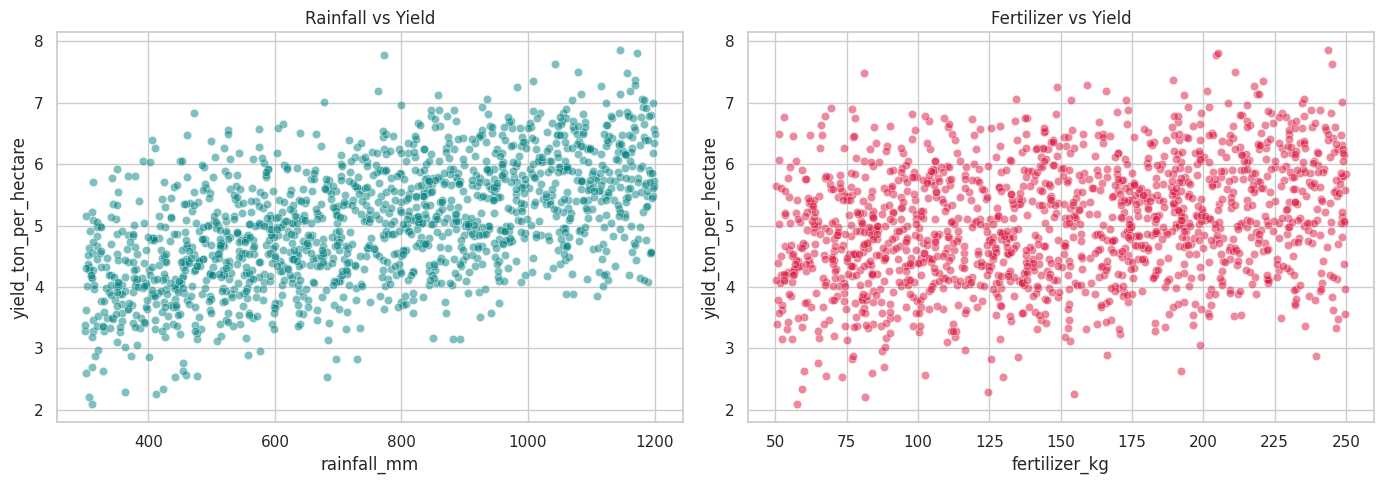

Correlation (rainfall_mm, yield): 0.554
Correlation (fertilizer_kg, yield): 0.278


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='rainfall_mm', y='yield_ton_per_hectare', alpha=0.5, ax=axes[0], color='teal')
axes[0].set_title('Rainfall vs Yield')

sns.scatterplot(data=df, x='fertilizer_kg', y='yield_ton_per_hectare', alpha=0.5, ax=axes[1], color='crimson')
axes[1].set_title('Fertilizer vs Yield')

plt.tight_layout()
plt.show()

corr_rainfall = df['rainfall_mm'].corr(df['yield_ton_per_hectare'])
corr_fertilizer = df['fertilizer_kg'].corr(df['yield_ton_per_hectare'])
print(f"Correlation (rainfall_mm, yield): {corr_rainfall:.3f}")
print(f"Correlation (fertilizer_kg, yield): {corr_fertilizer:.3f}")

**Answer:** `rainfall_mm` shows a clearer upward trend with yield (correlation ≈ 0.55) compared to `fertilizer_kg` (correlation ≈ 0.28), whose points are more scattered with a weaker trend. So **rainfall appears to have a stronger relationship with yield** than fertilizer.

## Q9. Correlation Analysis
- Generate a correlation matrix for numerical features.
- Create a heatmap.
- Identify the top three features most correlated with crop yield.

In [16]:
# Correlation matrix for numerical features
corr_matrix = df.select_dtypes(include=[np.number]).corr()
corr_matrix

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


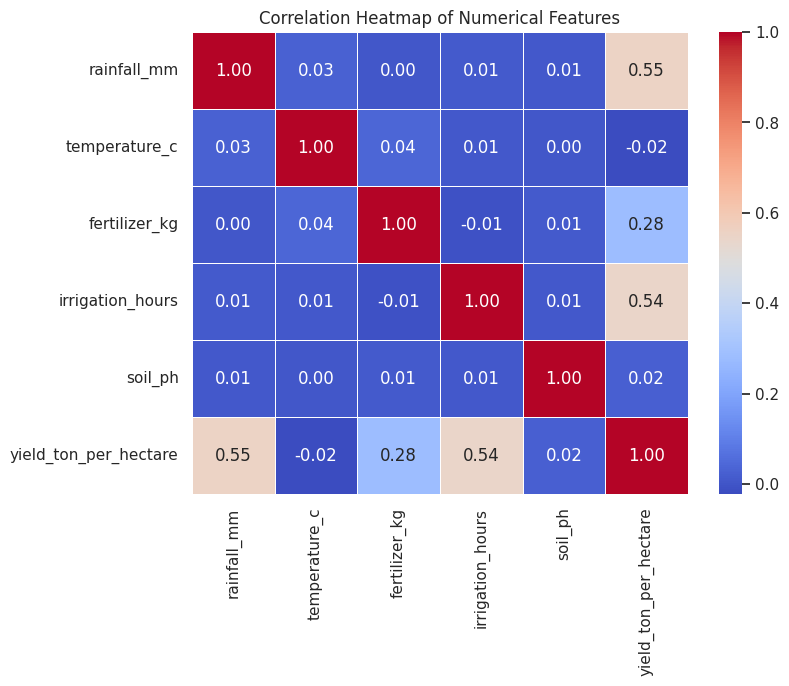

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [18]:
# Top 3 features most correlated with yield (excluding yield itself)
yield_corr = corr_matrix['yield_ton_per_hectare'].drop('yield_ton_per_hectare').sort_values(key=abs, ascending=False)
print("Correlation of each feature with yield_ton_per_hectare (sorted by strength):")
print(yield_corr)

print("\n>> Top 3 features most correlated with yield:")
print(yield_corr.head(3))

Correlation of each feature with yield_ton_per_hectare (sorted by strength):
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
soil_ph             0.024412
temperature_c      -0.022559
Name: yield_ton_per_hectare, dtype: float64

>> Top 3 features most correlated with yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


**Answer:** The top three features most correlated with `yield_ton_per_hectare` are:
1. **`rainfall_mm`** (≈ 0.55)
2. **`irrigation_hours`** (≈ 0.54)
3. **`fertilizer_kg`** (≈ 0.28)

`soil_ph` and `temperature_c` show almost no linear correlation with yield (both close to 0).

## Q10. Group-Based Analysis
Calculate the average yield for:
- Each crop type
- Each soil type

Which crop and soil type have the highest average yield?

In [19]:
avg_yield_by_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("Average yield by crop type:")
print(avg_yield_by_crop)

print(f"\n>> Crop with highest average yield: '{avg_yield_by_crop.idxmax()}' ({avg_yield_by_crop.max():.2f} ton/hectare)")

Average yield by crop type:
crop_type
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Maize      4.897143
Cotton     4.607299
Name: yield_ton_per_hectare, dtype: float64

>> Crop with highest average yield: 'Rice' (5.49 ton/hectare)


In [20]:
avg_yield_by_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("Average yield by soil type:")
print(avg_yield_by_soil)

print(f"\n>> Soil type with highest average yield: '{avg_yield_by_soil.idxmax()}' ({avg_yield_by_soil.max():.2f} ton/hectare)")

Average yield by soil type:
soil_type
Loamy    5.366519
Clay     5.134326
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

>> Soil type with highest average yield: 'Loamy' (5.37 ton/hectare)


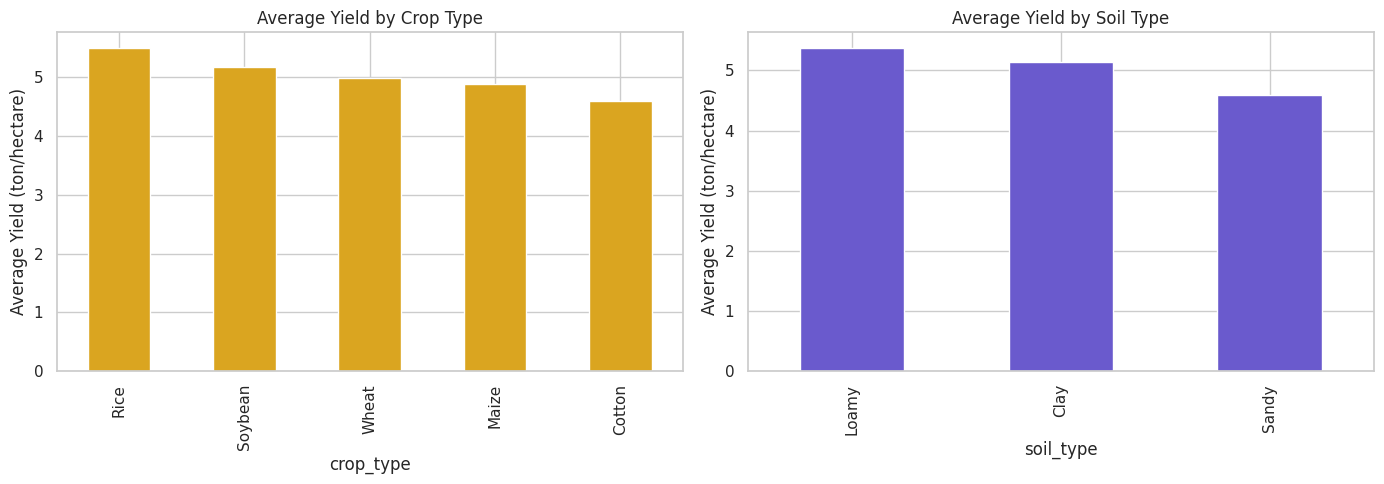

In [21]:
# Visualizing both group-based averages
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_yield_by_crop.plot(kind='bar', ax=axes[0], color='goldenrod')
axes[0].set_title('Average Yield by Crop Type')
axes[0].set_ylabel('Average Yield (ton/hectare)')

avg_yield_by_soil.plot(kind='bar', ax=axes[1], color='slateblue')
axes[1].set_title('Average Yield by Soil Type')
axes[1].set_ylabel('Average Yield (ton/hectare)')

plt.tight_layout()
plt.show()

**Answer:** `Rice` has the highest average yield among crop types (≈ 5.49 ton/hectare), and `Loamy` soil has the highest average yield among soil types (≈ 5.37 ton/hectare).

# Part C: Data Preparation

## Q11. Feature Encoding
- Identify the categorical columns.
- Convert them into numerical form using One-Hot Encoding.
- Display the first five rows of the transformed dataset.

In [22]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

Categorical columns: ['crop_type', 'soil_type']


/tmp/ipykernel_633/224175762.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [23]:
# One-Hot Encoding (drop_first=True avoids redundant/duplicate columns)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (1500, 12)


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


**Answer:** The categorical columns are `crop_type` and `soil_type`. After applying One-Hot Encoding (with `drop_first=True` to avoid redundancy), each category becomes its own binary (0/1) column, e.g. `crop_type_Maize`, `crop_type_Rice`, `soil_type_Loamy`, etc.

## Q12. Feature Selection
Separate:
- Input features (X)
- Target variable (y)

Specify which column is being used as the target variable.

In [24]:
# Target variable: yield_ton_per_hectare
target_column = 'yield_ton_per_hectare'

X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]

print(f"Target variable (y): '{target_column}'")
print(f"\nInput features (X) -> shape: {X.shape}")
print("Feature columns:", list(X.columns))
print(f"\nTarget (y) -> shape: {y.shape}")

Target variable (y): 'yield_ton_per_hectare'

Input features (X) -> shape: (1500, 11)
Feature columns: ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Soybean', 'crop_type_Wheat', 'soil_type_Loamy', 'soil_type_Sandy']

Target (y) -> shape: (1500,)


**Answer:** `yield_ton_per_hectare` is used as the **target variable (y)**. All remaining columns (the original numerical features plus the one-hot encoded crop/soil columns) form the **input features (X)**.

# Part D: Machine Learning

## Q13. Train-Test Split
Split the dataset into:
- 80% Training Data
- 20% Testing Data

Display the shape of:
- X_train
- X_test
- y_train
- y_test

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1200, 11)
X_test shape : (300, 11)
y_train shape: (1200,)
y_test shape : (300,)


**Answer:** The dataset (1500 rows) was split into 1200 training rows (80%) and 300 testing rows (20%), using `train_test_split` with `random_state=42` for reproducibility.

## Q14. Linear Regression Model
- Train a Linear Regression model.
- Display the model coefficients and intercept.
- Which feature has the highest positive coefficient?

In [26]:
# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Model performance
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)
print(f"Training R^2 score: {train_r2:.4f}")
print(f"Testing R^2 score : {test_r2:.4f}")

Training R^2 score: 0.8703
Testing R^2 score : 0.8628


In [27]:
# Coefficients and intercept
coefficients = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)

print("Model Intercept:", model.intercept_)
print("\nModel Coefficients (sorted, highest to lowest):")
print(coefficients)

print(f"\n>> Feature with the HIGHEST POSITIVE coefficient: '{coefficients.idxmax()}' ({coefficients.max():.4f})")

Model Intercept: 1.587132027736128

Model Coefficients (sorted, highest to lowest):
crop_type_Rice       0.863993
crop_type_Soybean    0.481719
crop_type_Wheat      0.348474
soil_type_Loamy      0.302974
crop_type_Maize      0.238931
irrigation_hours     0.198327
fertilizer_kg        0.004978
soil_ph              0.004901
rainfall_mm          0.002035
temperature_c       -0.009175
soil_type_Sandy     -0.490933
dtype: float64

>> Feature with the HIGHEST POSITIVE coefficient: 'crop_type_Rice' (0.8640)


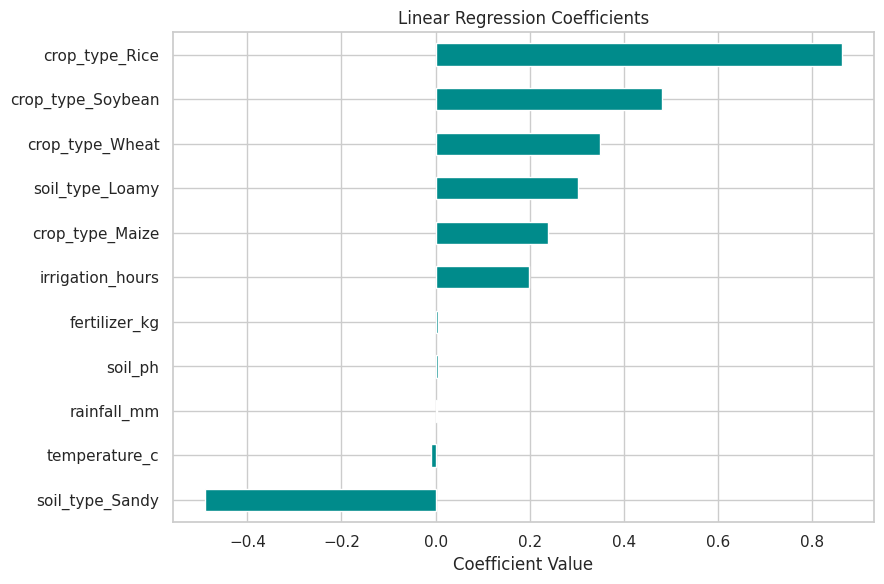

In [28]:
# Visualize the coefficients
plt.figure(figsize=(9, 6))
coefficients.plot(kind='barh', color='darkcyan')
plt.title('Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()